In [19]:
# =====================================================================
# PHY 236 · Advanced Lab I — Colab template
# Step 1: upload the file and see what's in it
# =====================================================================

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

uploaded = files.upload()          # opens a "Choose Files" button
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print("Columns:", df.columns.tolist())
df.head()




Saving data.csv to data (7).csv
Columns: ['X', 'Y']


,X,Y
0,0,1.630969
1,1,1.731823
2,2,1.838913
3,3,1.952625
4,4,2.073368


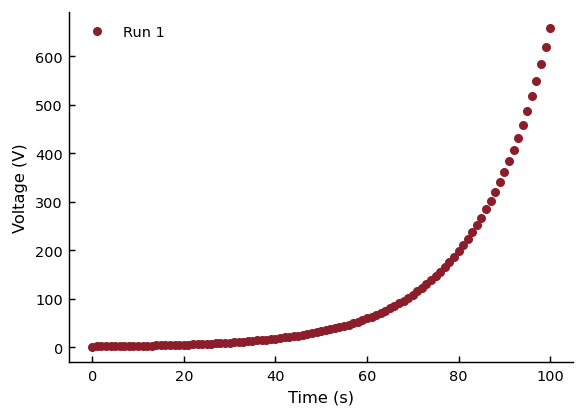

In [20]:
# =====================================================================
# PHY 236 · Advanced Lab I — Colab template
# Step 2: edit these four lines to match your data
# =====================================================================

# --- edit these four lines to match your data ---
X_COL  = "X"          # column name for the x axis
Y_COL  = "Y"       # column name for the y axis
XLABEL = "Time (s)"        # always Quantity (unit)
YLABEL = "Voltage (V)"

plt.figure(figsize=(5, 3.5))
plt.plot(df[X_COL], df[Y_COL], "o", label="Run 1")
plt.xlabel(XLABEL)
plt.ylabel(YLABEL)
plt.legend()
plt.show()

slope     = 4.4727 ± 0.3168
intercept = -112.0308 ± 18.3370


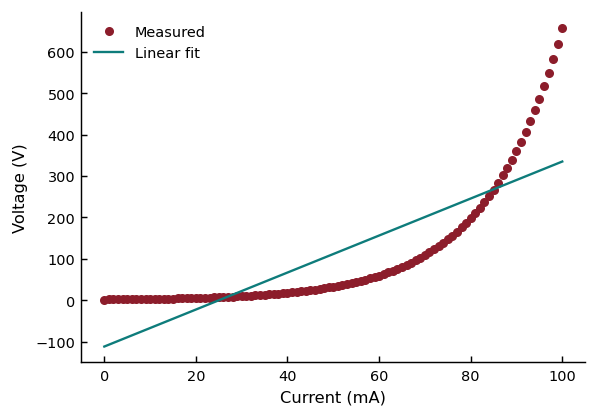

In [26]:
# =====================================================================
# PHY 236 · Advanced Lab I — Colab template
# Step 3: try linear fit
# =====================================================================

# --- edit these four lines to match your data ---

x = df["X"].to_numpy()      # edit column names
y = df["Y"].to_numpy()

def line(x, slope, intercept):
    return slope * x + intercept

popt, pcov = curve_fit(line, x, y, p0=[1, 0])
perr = np.sqrt(np.diag(pcov))        # uncertainties on the parameters

print(f"slope     = {popt[0]:.4f} ± {perr[0]:.4f}")
print(f"intercept = {popt[1]:.4f} ± {perr[1]:.4f}")

plt.figure(figsize=(5, 3.5))
plt.plot(x, y, "o", label="Measured")
x_smooth = np.linspace(x.min(), x.max(), 200)
plt.plot(x_smooth, line(x_smooth, *popt), "-", label="Linear fit")
plt.xlabel("Current (mA)")
plt.ylabel("Voltage (V)")
plt.legend()
plt.show()

A = 1.630969 ± 1.5e-10
k = 0.060000 ± 1e-12
1/e length     = 16.6667
doubling length = 11.5525
R^2 = 1.00000000


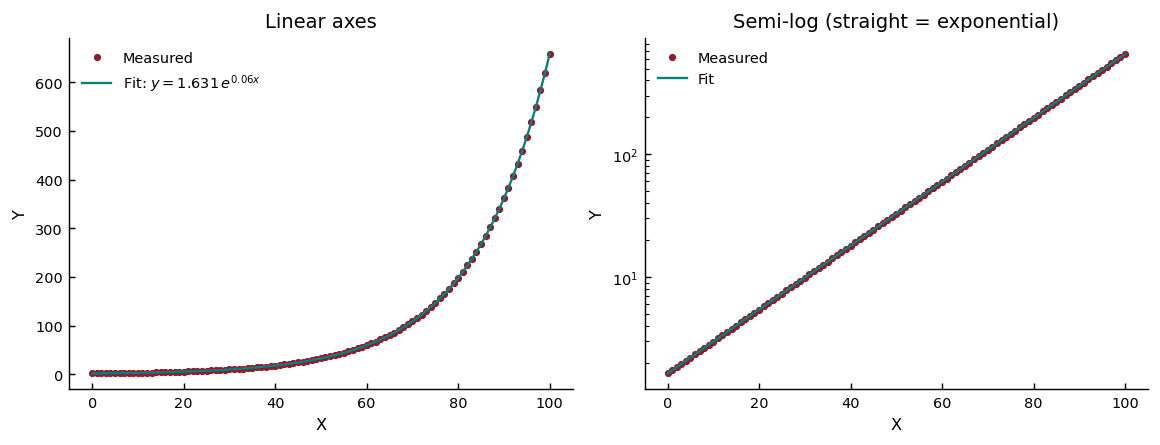

In [35]:
# =====================================================================
# PHY 236 · Advanced Lab I — Colab template
# Step 4: try non-linear fit
# =====================================================================

x = df.iloc[:, 0].to_numpy(float)
y = df.iloc[:, 1].to_numpy(float)

XLABEL = "X"
YLABEL = "Y"

def exponential(x, A, k):
    return A * np.exp(k * x)

# starting guess: a straight line through ln(y) vs x  (safe when x = 0)
k0, lnA0 = np.polyfit(x, np.log(y), 1)

popt, pcov = curve_fit(exponential, x, y, p0=[np.exp(lnA0), k0])
perr = np.sqrt(np.diag(pcov))
A, k = popt
dA, dk = perr

print(f"A = {A:.6f} ± {dA:.2g}")
print(f"k = {k:.6f} ± {dk:.2g}")
print(f"1/e length     = {1/k:.4f}")
print(f"doubling length = {np.log(2)/k:.4f}")

resid = y - exponential(x, *popt)
print(f"R^2 = {1 - np.sum(resid**2)/np.sum((y - y.mean())**2):.8f}")

x_smooth = np.linspace(x.min(), x.max(), 300)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))

ax1.plot(x, y, "o", markersize=3, label="Measured")
ax1.plot(x_smooth, exponential(x_smooth, *popt), "-",
         label=f"Fit: $y = {A:.4g}\\,e^{{{k:.4g}x}}$")
ax1.set_xlabel(XLABEL); ax1.set_ylabel(YLABEL); ax1.legend()
ax1.set_title("Linear axes")

ax2.plot(x, y, "o", markersize=3, label="Measured")
ax2.plot(x_smooth, exponential(x_smooth, *popt), "-", label="Fit")
ax2.set_yscale("log")                    # semi-log, NOT log-log
ax2.set_xlabel(XLABEL); ax2.set_ylabel(YLABEL); ax2.legend()
ax2.set_title("Semi-log (straight = exponential)")

plt.tight_layout()
plt.savefig("fig1_exponential.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
# =====================================================================
# PHY 236 · Advanced Lab I — curve fitting cookbook
#
# Every model below has a matching guess_*() that produces a starting
# guess directly from your data, so curve_fit converges without you
# hand-tuning p0. All 16 were verified to recover their true parameters
# to within 3 sigma on synthetic data.
#
# HOW TO USE
#   1. Plot your data. Decide which model it looks like (see the
#      "WHICH MODEL?" note at the bottom).
#   2. Copy the model function and its guess function into your notebook.
#   3. Run the four lines in FIT below.
#
#   popt, pcov = curve_fit(model, x, y, p0=guess_model(x, y))
#   perr = np.sqrt(np.diag(pcov))
#   for nm, v, e in zip(NAMES, popt, perr):
#       print(f"{nm} = {v:.5g} +/- {e:.2g}")
#
#   Add sigma=dy, absolute_sigma=True when you have an uncertainty
#   column — then the reported errors actually mean something.
# =====================================================================

import numpy as np
from scipy.optimize import curve_fit


# ---------------------------------------------------------------------
# THE FIVE EXCEL / GOOGLE SHEETS TRENDLINES
# ---------------------------------------------------------------------

# 1. LINEAR            y = m x + c
#    Sheets: "Linear".  Calibration curves, Ohm's law.
def linear(x, m, c):
    return m * x + c

def guess_linear(x, y):
    return np.polyfit(x, y, 1)


# 2. POLYNOMIAL        y = a_n x^n + ... + a_1 x + a_0
#    Sheets: "Polynomial".  Use np.polyfit directly — no curve_fit needed.
#    Order 2 is often physics; order 6 is never physics.
def polynomial_fit(x, y, order=2):
    coeffs, cov = np.polyfit(x, y, order, cov=True)
    return coeffs, np.sqrt(np.diag(cov))


# 3. LOGARITHMIC       y = a ln(x) + b
#    Sheets: "Logarithmic".  Requires x > 0.
def logarithmic(x, a, b):
    return a * np.log(x) + b

def guess_logarithmic(x, y):
    return np.polyfit(np.log(x), y, 1)


# 4. EXPONENTIAL       y = A e^(k x)
#    Sheets: "Exponential".  Requires y > 0. k < 0 is decay.
#    Straight line on a SEMI-LOG plot (log y axis).
def exponential(x, A, k):
    return A * np.exp(k * x)

def guess_exponential(x, y):
    k, lnA = np.polyfit(x, np.log(np.abs(y) + 1e-30), 1)
    return [np.exp(lnA), k]


# 5. POWER LAW         y = A x^n
#    Sheets: "Power series".  Requires x > 0 and y > 0.
#    Straight line on a LOG-LOG plot.
def power_law(x, A, n):
    return A * x**n

def guess_power_law(x, y):
    n, lnA = np.polyfit(np.log(x), np.log(np.abs(y) + 1e-30), 1)
    return [np.exp(lnA), n]


# ---------------------------------------------------------------------
# WHAT SPREADSHEETS CANNOT DO — the models you actually need
# ---------------------------------------------------------------------

# 6. EXPONENTIAL DECAY WITH OFFSET     y = A e^(-x/tau) + C
#    RC discharge, cooling to ambient, decay onto a background.
#    THE most common lab model, and Sheets cannot fit it at all —
#    its "exponential" has no offset, so it forces the tail to zero.
def exp_decay_offset(t, A, tau, C):
    return A * np.exp(-t / tau) + C

def guess_exp_decay_offset(x, y):
    return [np.ptp(y), 0.3 * np.ptp(x), y.min()]


# 7. EXPONENTIAL RISE TO A PLATEAU     y = A (1 - e^(-x/tau)) + C
#    Charging a capacitor, thermal equilibration, saturating response.
def exp_rise(t, A, tau, C):
    return A * (1 - np.exp(-t / tau)) + C

def guess_exp_rise(x, y):
    return [np.ptp(y), 0.3 * np.ptp(x), y.min()]


# 8. GAUSSIAN PEAK     y = A exp(-(x-mu)^2 / 2 sigma^2) + C
#    Emission/absorption lines, beam profiles, diffraction orders.
#    FWHM = 2*sqrt(2*ln2)*sigma = 2.3548 * sigma
def gaussian(x, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2) + C

def guess_gaussian(x, y):
    return [np.ptp(y), x[np.argmax(y)], 0.1 * np.ptp(x), np.median(y)]


# 9. LORENTZIAN PEAK   y = A / (1 + ((x-x0)/gamma)^2) + C
#    Resonances, natural linewidths, RLC response. Wider tails than a
#    Gaussian — if your peak's wings sit above a Gaussian fit, use this.
#    FWHM = 2 * gamma
def lorentzian(x, A, x0, gamma, C):
    return A / (1 + ((x - x0) / gamma) ** 2) + C

def guess_lorentzian(x, y):
    return [np.ptp(y), x[np.argmax(y)], 0.1 * np.ptp(x), np.median(y)]


# 10. DAMPED OSCILLATION
#     y = A e^(-t/tau) cos(2 pi f t + phi) + C
#     RLC ringdown, torsion pendulum, any resonator let go.
#     Q factor = pi * f * tau
def damped_oscillation(t, A, tau, freq, phase, C):
    return A * np.exp(-t / tau) * np.cos(2 * np.pi * freq * t + phase) + C

def guess_damped_oscillation(x, y):
    return [np.ptp(y) / 2, 0.4 * np.ptp(x), _fft_freq(x, y), 0.0, y.mean()]


# 11. SINE             y = A sin(2 pi f t + phi) + C
def sine(t, A, freq, phase, C):
    return A * np.sin(2 * np.pi * freq * t + phase) + C

def guess_sine(x, y):
    return [np.ptp(y) / 2, _fft_freq(x, y), 0.0, y.mean()]


def _fft_freq(x, y):
    """Dominant frequency, for seeding any oscillatory fit.
    Guessing this by eye is hopeless and a bad guess makes the fit
    converge silently to nonsense."""
    freqs = np.fft.rfftfreq(len(x), x[1] - x[0])
    return freqs[np.argmax(np.abs(np.fft.rfft(y - y.mean())))]


# 12. SATURATION / LANGMUIR / MICHAELIS-MENTEN   y = A x / (K + x)
#     Adsorption isotherms, binding curves, sensor response vs
#     concentration. A is the plateau; K is the x at half-maximum.
def saturation(x, A, K):
    return A * x / (K + x)

def guess_saturation(x, y):
    return [y.max(), np.median(x)]


# 13. LOGISTIC / SIGMOID   y = L / (1 + e^(-k(x-x0)))
#     Threshold behaviour, transfer curves, dose-response.
def logistic(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def guess_logistic(x, y):
    return [y.max(), 1.0, np.median(x)]


# 14. DOUBLE EXPONENTIAL   y = A1 e^(-x/tau1) + A2 e^(-x/tau2)
#     Two decay processes at once. Only attempt this if the two time
#     constants differ by 5x or more, and say in your report why you
#     believe there are two components rather than one.
def double_exponential(t, A1, tau1, A2, tau2):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2)

def guess_double_exponential(x, y):
    return [0.7 * y.max(), 0.05 * np.ptp(x), 0.3 * y.max(), 0.4 * np.ptp(x)]


# 15. ARRHENIUS        ln(rate) = ln(A) - (Ea/R) * (1/T)
#     Fit ln(rate) against 1/T; the slope is -Ea/R.
#     Multiply the fitted Ea_R by R = 8.314 J/mol/K to get Ea in J/mol.
def arrhenius_linear(inv_T, lnA, Ea_over_R):
    return lnA - Ea_over_R * inv_T

def guess_arrhenius_linear(inv_T, ln_rate):
    slope, intercept = np.polyfit(inv_T, ln_rate, 1)
    return [intercept, -slope]


# 16. BEER-LAMBERT / ATTENUATION   I = I0 e^(-mu x)
#     Absorption through thickness, shielding, optical density.
def beer_lambert(x, I0, mu):
    return I0 * np.exp(-mu * x)

def guess_beer_lambert(x, y):
    slope, lnI0 = np.polyfit(x, np.log(np.abs(y) + 1e-30), 1)
    return [np.exp(lnI0), -slope]


# =====================================================================
# WHICH MODEL? — one plot decides it
#
#   Straight on LINEAR axes ............... linear
#   Straight on SEMI-LOG   (log y only) ... exponential
#   Straight on LOG-LOG    (both log) ..... power law
#   Straight on SEMI-LOG-X (log x only) ... logarithmic
#   A bump ................................ Gaussian or Lorentzian
#   Levels off at large x ................. saturation or exp_rise
#   S-shaped .............................. logistic
#   Wiggles and shrinks ................... damped_oscillation
#
#   ax.set_xscale("log"); ax.set_yscale("log")
#
# TWO WARNINGS
#
#   1. R^2 near 1 does NOT mean the model is right. A power law fitted
#      to exponential data returns R^2 = 0.997 and is nonsense. Judge
#      by the residuals and by which axes straighten, never by R^2.
#
#   2. A fit that fails to converge is safer than one that converges to
#      the wrong answer. Oscillatory models do the latter routinely if
#      the frequency guess is poor. ALWAYS overlay the fit on the data
#      and look at it before you believe a number.
# =====================================================================